# Nome: Wesley Rafael da Silva  RA: 625105397
# Turma: A Serie: 01 Turno: Noturno

Solução Apresentada utilizando modelo pre-treinado Resnet18


In [ ]:
# Instalar Dependências
!pip install torch torchvision scikit-learn

# Importações
import os
import zipfile
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import classification_report, confusion_matrix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 102.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [ ]:
# Configurações de dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Usando dispositivo: {device}")

 Usando dispositivo: cuda


In [ ]:
# Definir URLs
background_url = "https://www.dropbox.com/scl/fo/myx9nxbavqi073ll365qo/AJWKN4UAPvlIa5n8ZUHWST4/Background?rlkey=3h0kub8j36rthlwos741vh78h&dl=1"
pedestrian_url = "https://www.dropbox.com/scl/fo/myx9nxbavqi073ll365qo/AAPMm6XJI96pJd5QXC08toA/Pedestrians?rlkey=3h0kub8j36rthlwos741vh78h&dl=1"


In [ ]:
# Download e Preparação do Dataset
os.makedirs("data_pedestrian", exist_ok=True)

In [ ]:
# Baixar arquivos
!wget -O background.zip "$background_url"
!wget -O pedestrian.zip "$pedestrian_url"

# Descompactar
with zipfile.ZipFile("background.zip", "r") as zip_ref:
    zip_ref.extractall("data_pedestrian/Background")

with zipfile.ZipFile("pedestrian.zip", "r") as zip_ref:
    zip_ref.extractall("data_pedestrian/Pedestrians")

--2025-06-08 18:10:58--  https://www.dropbox.com/scl/fo/myx9nxbavqi073ll365qo/AJWKN4UAPvlIa5n8ZUHWST4/Background?rlkey=3h0kub8j36rthlwos741vh78h&dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.1.18, 2620:100:6016:18::a27d:112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.1.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc4a2d23d1f7de7644ac182e3a66.dl.dropboxusercontent.com/zip_download_get/COrC9Bo4fwJYCyABOxxM-8PNy034fQew8p2T8-QRdDFs0yxC-bLA1B1nemO-0X8VOKAFUHcmN5rvbbOsOLVjBr3d2flrKIU0HxWoHnWNpoZWvw# [following]
--2025-06-08 18:11:00--  https://uc4a2d23d1f7de7644ac182e3a66.dl.dropboxusercontent.com/zip_download_get/COrC9Bo4fwJYCyABOxxM-8PNy034fQew8p2T8-QRdDFs0yxC-bLA1B1nemO-0X8VOKAFUHcmN5rvbbOsOLVjBr3d2flrKIU0HxWoHnWNpoZWvw
Resolving uc4a2d23d1f7de7644ac182e3a66.dl.dropboxusercontent.com (uc4a2d23d1f7de7644ac182e3a66.dl.dropboxusercontent.com)... 162.125.1.15, 2620:100:6016:15::a27d:10f
Connecting to uc4a2d23d1f7de7644ac18

In [ ]:
# Organizar estrutura
dataset_path = "data_pedestrian/dataset"
os.makedirs(dataset_path, exist_ok=True)

shutil.move("data_pedestrian/Background", os.path.join(dataset_path, "background"))
shutil.move("data_pedestrian/Pedestrians", os.path.join(dataset_path, "pedestrian"))

print(" Dataset preparado em:", dataset_path)

 Dataset preparado em: data_pedestrian/dataset


In [ ]:
# Transformações
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [ ]:
# Carregar Dataset
full_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
print(f" Total de imagens: {len(full_dataset)}")
print(f" Classes: {full_dataset.classes}")


 Total de imagens: 5406
 Classes: ['background', 'pedestrian']


In [ ]:
# Divisão treino, val, teste
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f" Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

 Train: 3784, Val: 810, Test: 812


In [ ]:
# DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# Modelo ResNet18
resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in resnet18.parameters():
    param.requires_grad = False

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 163MB/s]


In [ ]:
# Substituir a última camada
num_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_features, 2)
resnet18 = resnet18.to(device)
print(resnet18)

# Funções auxiliares
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet18.fc.parameters(), lr=0.001)

def accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    return torch.sum(preds == labels).item() / len(labels)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
#Loop de Treinamento
import os
import torch

# Configuração
num_epochs = 10
modelo_path = 'modelos/melhor_modelo_resnet18.pth'

# Cria a pasta (se não existir)
os.makedirs('modelos', exist_ok=True)

best_val_acc = 0
best_model_wts = None  # Guarda os melhores pesos com base na validação

print(f"{'Época':>7} {'Train Loss':>12} {'Train Acc':>12} | {'Val Loss':>10} {'Val Acc':>10}")
print("-" * 65)

for epoch in range(num_epochs):
    print(f"Época {epoch+1}/{num_epochs}")

    # Treinamento
    resnet18.train()
    train_loss, train_acc = 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = resnet18(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)
        train_acc += accuracy(outputs, labels) * inputs.size(0)
    train_loss /= train_size
    train_acc /= train_size

    # Validação
    resnet18.eval()
    val_loss, val_acc = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet18(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            val_acc += accuracy(outputs, labels) * inputs.size(0)
    val_loss /= val_size
    val_acc /= val_size

    print(f"{epoch+1:7} {train_loss:12.4f} {train_acc:12.4f} | {val_loss:10.4f} {val_acc:10.4f}")

    # Verifica o melhor modelo até agora
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = resnet18.state_dict()

print("\nTreinamento finalizado.")
print(f"Melhor acurácia de validação: {best_val_acc:.4f}")


  Época   Train Loss    Train Acc |   Val Loss    Val Acc
-----------------------------------------------------------------
Época 1/10
      1       0.0277       0.9913 |     0.0159     0.9951
Época 2/10
      2       0.0288       0.9905 |     0.0122     0.9988
Época 3/10
      3       0.0321       0.9865 |     0.0119     0.9975
Época 4/10
      4       0.0173       0.9945 |     0.0130     0.9975
Época 5/10
      5       0.0186       0.9950 |     0.0120     0.9975
Época 6/10
      6       0.0176       0.9939 |     0.0113     0.9988
Época 7/10
      7       0.0185       0.9955 |     0.0138     0.9938
Época 8/10
      8       0.0160       0.9947 |     0.0117     0.9963
Época 9/10
      9       0.0175       0.9952 |     0.0192     0.9938
Época 10/10
     10       0.0204       0.9929 |     0.0109     0.9975

Treinamento finalizado.
Melhor acurácia de validação: 0.9988


In [ ]:
# Salva o melhor modelo
torch.save(best_model_wts, modelo_path)
print(" Melhor modelo salvo.")

 Melhor modelo salvo.


In [ ]:
# Avaliação
resnet18.eval()
val_loss, val_acc = 0, 0
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = resnet18(inputs)
        loss = criterion(outputs, labels)
        val_loss += loss.item() * inputs.size(0)
        val_acc += accuracy(outputs, labels) * inputs.size(0)

val_loss /= val_size
val_acc /= val_size


print(f"{epoch+1:>7} {train_loss:12.4f} {train_acc:12.4f} | {val_loss:10.4f} {val_acc:10.4f}")

# Se a acurácia de validação for melhor, salva o modelo
if val_acc > best_val_acc:
    best_val_acc = val_acc
    torch.save(resnet18.state_dict(), modelo_path)
    print(f" melhor modelo salvo {epoch+1} com Val Acc = {val_acc:.4f}")

     10       0.0204       0.9929 |     0.0109     0.9975


In [ ]:
# Relatório de Classificação e Matriz de Confusão
resnet18.load_state_dict(torch.load(modelo_path))
resnet18.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = resnet18(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\n Relatório de Classificação:")
print(classification_report(all_labels, all_preds, target_names=full_dataset.classes))
print(" Matriz de Confusão:")
print(confusion_matrix(all_labels, all_preds))


 Relatório de Classificação:
              precision    recall  f1-score   support

  background       0.99      0.99      0.99       475
  pedestrian       0.99      0.99      0.99       337

    accuracy                           0.99       812
   macro avg       0.99      0.99      0.99       812
weighted avg       0.99      0.99      0.99       812

 Matriz de Confusão:
[[470   5]
 [  4 333]]


In [ ]:
# Visualização
def visualizar_amostras(classe, num_imagens=6):
    idxs = [i for i, (_, label) in enumerate(full_dataset) if full_dataset.classes[label] == classe]
    if not idxs:
        print(f"Nenhuma imagem encontrada para a classe: {classe}")
        return

    amostras = random.sample(idxs, min(num_imagens, len(idxs)))

    resnet18.eval()
    with torch.no_grad():
        for idx in amostras:
            img, _ = full_dataset[idx]
            input_img = img.unsqueeze(0).to(device)
            output = resnet18(input_img)
            _, pred = torch.max(output, 1)
            pred_label = full_dataset.classes[pred.item()]

            mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1).to(img.device)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1).to(img.device)
            img_show = img * std + mean
            img_show = img_show.clamp(0, 1)

            titulo = "Pedestre" if pred_label == "pedestrian" else "Não Pedestre"

            plt.figure(figsize=(4,4))
            plt.title(titulo)
            plt.imshow(np.transpose(img_show.cpu().numpy(), (1, 2, 0)))
            plt.axis('off')
            plt.show()

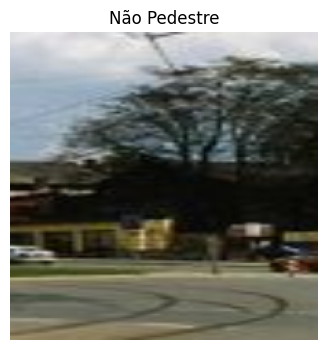

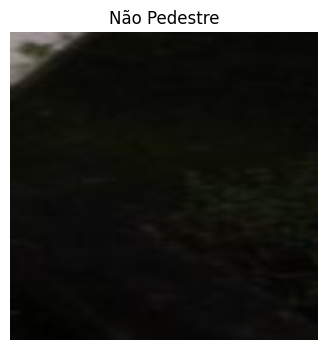

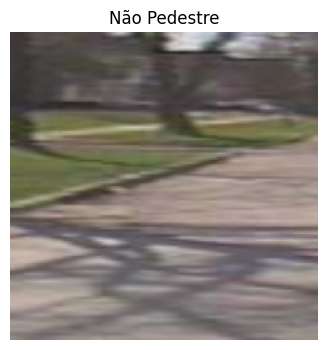

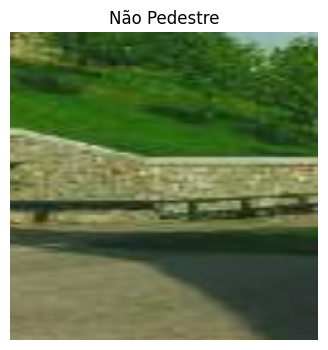

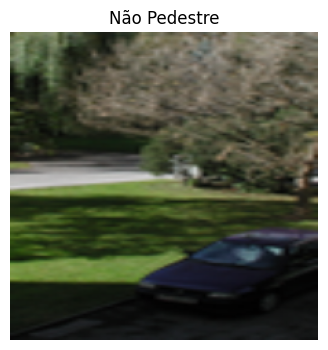

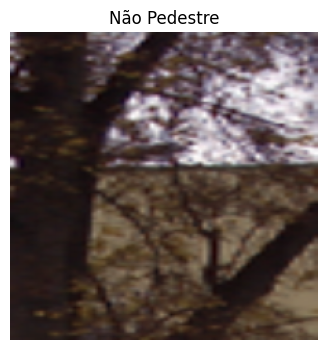

In [ ]:
visualizar_amostras('background', 6)

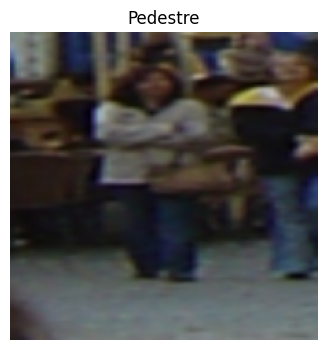

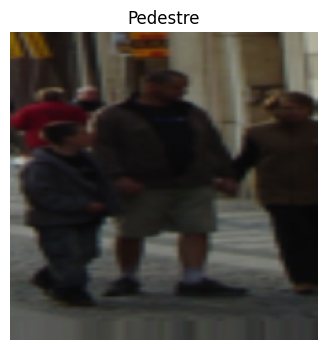

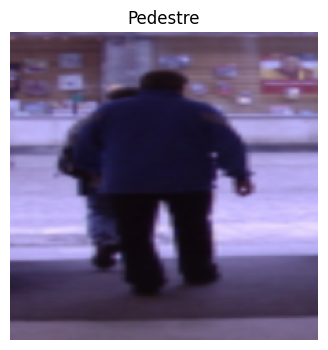

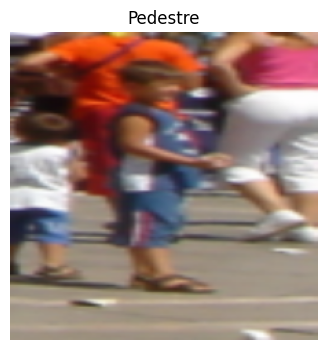

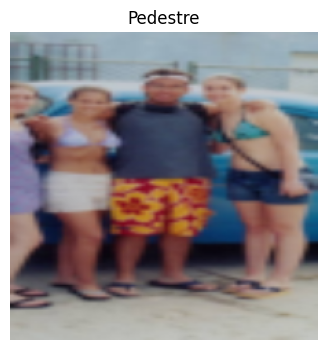

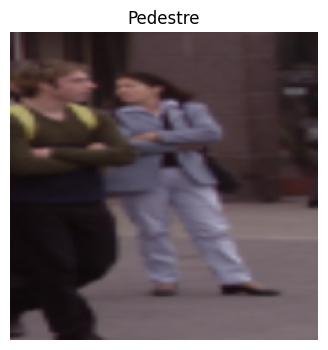

In [ ]:
visualizar_amostras('pedestrian', 6)